In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
import pandas as pd

train_df = pd.read_csv("customer_churn_dataset-testing-master.csv")
test_df = pd.read_csv("customer_churn_dataset-training-master.csv")

In [4]:
print("Training Dataset Shape:", train_df.shape)
print("Testing Dataset Shape:", test_df.shape)

train_df.head()

Training Dataset Shape: (64374, 12)
Testing Dataset Shape: (440833, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [7]:
print(train_df.isnull().sum())

print("\n")

print(test_df.isnull().sum())

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


In [8]:
train_df = train_df.dropna()
test_df = test_df.dropna()

In [9]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ["Gender", "Subscription Type", "Contract Length"]

for col in categorical_cols:
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

In [11]:
X_train = train_df.drop(["CustomerID", "Churn"], axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop(["CustomerID", "Churn"], axis=1)
y_test = test_df["Churn"]

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [14]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, y_true, y_pred):
    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

In [17]:
evaluate_model("Logistic Regression", y_test, lr_pred)

Logistic Regression
Accuracy : 0.6325130662020906
Precision: 0.9764377213024222
Recall   : 0.3607014428057712
F1 Score : 0.5268000584197459

Confusion Matrix
[[188657   2176]
 [159824  90175]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.54      0.99      0.70    190833
         1.0       0.98      0.36      0.53    249999

    accuracy                           0.63    440832
   macro avg       0.76      0.67      0.61    440832
weighted avg       0.79      0.63      0.60    440832



In [18]:
evaluate_model("Decision Tree", y_test, dt_pred)

Decision Tree
Accuracy : 0.58384600029036
Precision: 0.9801988771666498
Recall   : 0.2716690866763467
F1 Score : 0.4254278269148856

Confusion Matrix
[[189461   1372]
 [182082  67917]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.51      0.99      0.67    190833
         1.0       0.98      0.27      0.43    249999

    accuracy                           0.58    440832
   macro avg       0.75      0.63      0.55    440832
weighted avg       0.78      0.58      0.53    440832



In [19]:
evaluate_model("Random Forest", y_test, rf_pred)

Random Forest
Accuracy : 0.5836894780778165
Precision: 0.9810687199675795
Recall   : 0.2711370845483382
F1 Score : 0.42485685901513986

Confusion Matrix
[[189525   1308]
 [182215  67784]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.51      0.99      0.67    190833
         1.0       0.98      0.27      0.42    249999

    accuracy                           0.58    440832
   macro avg       0.75      0.63      0.55    440832
weighted avg       0.78      0.58      0.53    440832



In [20]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.632513,0.976438,0.360701,0.526800
1,Decision Tree,0.583846,0.980199,0.271669,0.425428
2,Random Forest,0.583689,0.981069,0.271137,0.424857


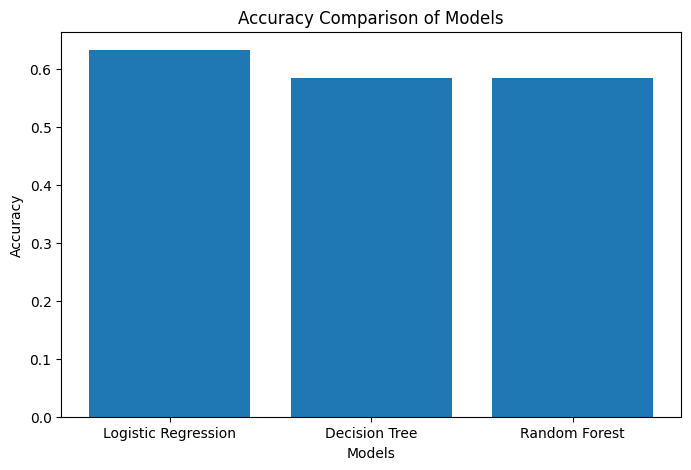

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Accuracy Comparison of Models")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [22]:
train_df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,52.631497
1,47.368503


Among the three classification models, Logistic Regression achieved the best overall performance with an accuracy of 63.25% and an F1-score of 52.68%. It also achieved the highest recall, making it more effective at identifying customers who are likely to churn. Therefore, Logistic Regression was selected as the final model for this customer churn prediction task.